# Practice 3. Optimization methods for Lasso regression

In this assignment we consider the following optimization problem:
$$
    F(\vec{w}) = \frac{1}{2N}\|X\vec{w} - \vec{y}\|_2^2 + \lambda\|\vec{w}\|_1\rightarrow\min_{\vec{w}}\quad (1)
$$
Here $X\in\mathbb{R}^{N{\times}D}$ - object-feature matrix, $\vec{y}\in\mathbb{R}^N$ - regression target variable, $\vec{w}\in\mathbb{R}^D$ - linear regression weights and $\lambda\ge 0$ - regularization coefficient.

In the assignment we're going to use several optimization methods: **1) Log-Barrier method** for some smooth constrained optimization problem that is equivalent to the problem (1), **2) Subgradient method** for direct solving of the initial non-smooth problem (1), **3) Proximal Gradient method** for the case when the problem (1) is interpreted as composite optimization problem and **4) ADMM method**.

The Lasso model (1) allows finding the sparse solution for $\vec{w}$. The larger the regularization parameter $\lambda$, the more weights in $\vec{w}$ will be zero. Also it is possible to prove that if
$$
    \lambda \ge \frac{1}{N}\|X^T\vec{y}\|_{\infty},\ \quad (2)
$$
then $\vec{w}_{opt} = \vec{0}$. So there is no reason to run optimization routines in cases, when $\lambda$ satisfies the condition (2).

## Part 1 (0.5 pts): duality gap implementation

In [1]:
# Some standard imports
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm  # useful for showing progress of optimization methods
import time  # for measuring iteration time inside optimizers
from sklearn.datasets import load_svmlight_file  # useful for loading data from svmlight collection of datasets

### Duality gap for the Lasso problem

Using the idea of dual decomposition, the initial optimization problem (1) can be equivalently rewritten as:
\begin{align*}
    &\frac{1}{2N}\|\vec{z}\|_2^2 + \lambda\|\vec{w}\|_1\rightarrow\min_{\vec{z},\vec{w}},\\
    &\vec{z} = X\vec{w} - \vec{y}.
\end{align*}
The dual optimization problem for this primal one is the following:
\begin{align*}
    &-\frac{N}{2}\|\vec{\mu}\|_2^2 - \vec{\mu}^T\vec{y}\rightarrow\max_{\vec{\mu}},\\
    &\|X^T\vec{\mu}\|_{\infty}\le\lambda.
\end{align*}
The primal and dual variables are connected as follows: $\vec{z} = N\vec{\mu}$. Then using this dual formulation we can derive an upper bound to the current optimality:
$$
    F(\vec{w}) - F_{opt} \le \frac{1}{2N}\|X\vec{w} - \vec{y}\|_2^2 + \lambda\|\vec{w}\|_1 + \frac{N}{2}\|\vec{\mu}\|_2^2 + \vec{\mu}^T\vec{y}.\quad (3)
$$
Here $\vec{\mu} = \frac{1}{N}\vec{z} = \frac{1}{N}(X\vec{w}-\vec{y})$ and should satisfy the constraints $\|X^T\vec{\mu}\|_{\infty}\le\lambda$. This can be ensured by the following formula:
$$
    \vec{\mu} = \min\left(1, \frac{\lambda}{\frac{1}{N}\|X^T(X\vec{w}-\vec{y})\|_{\infty}}\right)\frac{1}{N}(X\vec{w}-\vec{y}).\quad (4)
$$

In this assignment the upper bound (3), (4) for duality gap will be used as the universal stopping criterion for all optimization methods.

Also in this assignment we assume that the number of objects $N$ could be arbitrary large, but the number of features $D$ is reasonably small (few hundrends), so $D{\times}D$ matrix is convenient to work with. Hence it is reasonable in all procedures to precompute values like $X^TX$, $X^T\vec{y}$, etc. and never compute directly $X\vec{w}$.

In [2]:
def duality_gap(w, opt_problem):
    """
    Duality gap computation using formulas (3), (4)
    
    Inputs:
        w - current weights, the vector of size D
        opt_problem - optimization problem, dictionary with fields:
            'XX' - the matrix X^TX
            'Xy' - the product of X^T by the vector y
            'y2' - the value y^Ty, scalar
            'lambda' - regularization coefficient
            'N' - the number of objects
    
    Output:
        gap - the value of duality gap
    
    """

    # YOUR IMPLEMENTATION HERE
    XX = opt_problem['XX']
    Xy = opt_problem['Xy']
    y2 = opt_problem['y2']
    lambda_ = opt_problem['lambda']
    N = opt_problem['N']

    XTr = XX.dot(w) - Xy
    r2 = w.dot(XX.dot(w)) - 2.0 * w.dot(Xy) + y2
    primal = 0.5 * r2 / N + lambda_ * np.sum(np.abs(w))

    denom = np.max(np.abs(XTr)) / N
    if denom <= lambda_ or denom == 0:
        scale = 1.0
    else:
        scale = lambda_ / denom

    dual_correction = 0.5 * (scale ** 2) * r2 / N + scale * (w.dot(Xy) - y2) / N
    gap = primal + dual_correction
    return max(float(np.real(gap)), 0.0)

In [3]:
# Some checks

# Duality gap value for particular dataset
X = np.arange(80, dtype=np.float64).reshape(10,8)
y = np.arange(10, dtype=np.float64) - 5
XX = X.T.dot(X)
Xy = X.T.dot(y)
y2 = y.T.dot(y)
lambda_ = 1
opt_problem = {'XX': XX, 'Xy': Xy, 'y2': y2, 'lambda': lambda_, 'N': X.shape[0]}

w = np.arange(8, dtype=np.float64) - 4
gap = duality_gap(w, opt_problem)
assert abs(gap - 11178.2201955) < 1e-5

# Check that for lambda from the formula (2) duality gap for zero vector is zero
lambda_ = (1/X.shape[0])*np.max(np.abs(X.T.dot(y)))
opt_problem['lambda'] = lambda_
w = np.zeros(8)
gap = duality_gap(w, opt_problem)
assert gap < 1e-10

## Part 2 (3 pts): Logarithmic Barriers (primal interior-point method)

In this section we transform the Lasso problem (1) to specific Quadratic Programming formulation and solve it using Log-Barriers method:
\begin{align*}
    &\frac{1}{2N}\|X\vec{w} - \vec{y}\|_2^2 + \lambda\sum_{j=1}^Dt_j\rightarrow\min_{\vec{w},\vec{t}},\\
    &-t_j\le w_j\le t_j\ \forall j=1,\dots,D.
\end{align*}

Following the general scheme of Log-Barriers method, we consider the auxiliary optimization problem with centering parameter $\tau>0$:
$$
    F_{\tau}(\vec{w},\vec{t}) = \tau\left[\frac{1}{2N}\|X\vec{w} - \vec{y}\|_2^2 + \lambda\vec{t}^T\vec{1}\right] - \sum_{j=1}^D\log(t_j - w_j) - \sum_{j=1}^D\log(t_j + w_j)\rightarrow\min_{\vec{w},\vec{t}:|w_j|\le t_j}.\quad (5)
$$

Let's apply Newton method for solving the auxiliary problem (5). It means that we consider the method with iterations:
$$
    \vec{w}_{k+1} = \vec{w}_k + \alpha_k\vec{d}_k^w,\ \vec{t}_{k+1} = \vec{t}_k + \alpha_k\vec{d}_k^t,
$$
where the optimization direction $\vec{d}_k^w,\vec{d}_k^t$ is found by solving the following linear system:
$$
    \begin{bmatrix}
        \nabla^2_{ww}F_{\tau}(\vec{w}_k,\vec{t}_k) & \nabla^2_{wt}F_{\tau}(\vec{w}_k,\vec{t}_k)\\
        \nabla^2_{tw}F_{\tau}(\vec{w}_k,\vec{t}_k) & \nabla^2_{tt}F_{\tau}(\vec{w}_k,\vec{t}_k)
    \end{bmatrix}\begin{bmatrix}d_k^w\\d_k^t\end{bmatrix} = -\begin{bmatrix}\nabla_wF_{\tau}(\vec{w}_k,\vec{t}_k)\\ \nabla_tF_{\tau}(\vec{w}_k,\vec{t}_k)\end{bmatrix}\quad (6)
$$

The stepsize $\alpha_k$ can be chosen by backtracking procedure for the function $F_{\tau}$. It is important to start the backtracking in a way as not to violate the constaints $|w_{k+1,j}|\le t_{k+1,j}$. Here such maximal $\alpha_{start}$ can be found analytically:
$$
    \alpha_{start} = \min(1, 0.95\min(\alpha_1, \alpha_2)),\ \alpha_1 = \min_{j:d_{k,j}^w-d_{k,j}^t>0}\frac{t_{k,j}-w_{k,j}}{d_{k,j}^w-d_{k,j}^t},\ \alpha_2 = \min_{j:d_{k,j}^t+d_{k,j}^w<0}\frac{w_{k,j}+t_{k,j}}{-d_{k,j}^t - d_{k,j}^w}.\quad (7)
$$

### Task 2.1. Auxiliary function implementation (0.5 pts)

Let's first implement the auxiliary function (5) and its gradient for backtracking procedure

In [4]:
def aux_function(w, t, opt_problem, tau):
    """
    Compute the function value and its gradient for the auxiliary function (5)
    
    Inputs:
        w - current parameter w, a vector of size D
        t - current parameter t, a vector of size D
        opt_problem - optimization problem, dictionary with fields:
            'XX' - the matrix X^TX
            'Xy' - the vector X^Ty
            'y2' - the value y^Ty, scalar
            'lambda' - regularization coefficient
            'N' - the number of objects
        tau - centering parameter, positive scalar
        
    Outputs:
        f - function value, scalar
        g - gradient vector, a vector of size 2*D
    """
    
    # YOUR IMPLEMENTATION HERE
    XX = opt_problem['XX']
    Xy = opt_problem['Xy']
    y2 = opt_problem['y2']
    lambda_ = opt_problem['lambda']
    N = opt_problem['N']

    a = t - w
    b = t + w
    quad = 0.5 / N * (w.dot(XX.dot(w)) - 2.0 * w.dot(Xy) + y2)
    f = tau * (quad + lambda_ * np.sum(t)) - np.sum(np.log(a)) - np.sum(np.log(b))

    grad_w = tau / N * (XX.dot(w) - Xy) + 1.0 / a - 1.0 / b
    grad_t = tau * lambda_ * np.ones_like(t) - 1.0 / a - 1.0 / b
    g = np.concatenate([grad_w, grad_t])
    return f, g

In [5]:
# Some checks

# Check of the correspondence between function value and its gradient
# using finite difference scheme
N = 10
D = 8
X = np.random.randn(N, D)
y = np.random.randn(N)
XX = X.T.dot(X)
Xy = X.T.dot(y)
tau = 1e+4
lambda_ = 1
opt_problem = {'XX': XX, 'Xy': Xy, 'y2': y2, 'lambda': lambda_, 'N': N}

t = 10*np.random.rand(D)
w = (2*t)*np.random.rand(D) - t
f, g = aux_function(w, t, opt_problem, tau)
d_w = np.random.randn(D)
d_t = np.random.randn(D)
g1 = aux_function(w + 1e-14*1j*d_w, t + 1e-14*1j*d_t, opt_problem, tau)[0].imag / (1e-14)
assert np.max(np.abs(g[:D].dot(d_w) + g[D:].dot(d_t) - g1)) < 1e-9

### Task 2.2. Solving the Newton system (0.5 pts)

Derive the necessary derivatives for the linear system (6). The matrix $\nabla^2_{tt}F_{\tau}(\vec{w}_k,\vec{t}_k)$ is diagonal one. It means that the vector $d_k^t$ can be efficiently computed from the vector $d_k^w$ and the linear system (6) can be reduced to just $D{\times}D$ system for the vector $d_k^w$. Implement the solution for this system.

In [6]:
def newton_system_solve(w, t, opt_problem, tau, method='full'):
    """
    Solve the Newton linear system (6) in efficient way
    
    Inputs:
        w - current parameters w
        t - current parameters t
        opt_problem - optimization problem, dictionary with fields:
            'XX' - the matrix X^TX
            'Xy' - the vector X^Ty
            'lambda' - regularization coefficient
            'N' - the number of objects
        tau - centering parameter, scalar
    
    Outputs:
        d_w - optimization direction for vector w
        d_t - optimization direction for vector t
    """
    
    # YOUR IMPLEMENTATION HERE
    XX = opt_problem['XX']
    Xy = opt_problem['Xy']
    lambda_ = opt_problem['lambda']
    N = opt_problem['N']

    _, g = aux_function(w, t, opt_problem, tau)
    D = w.size
    g_w, g_t = g[:D], g[D:]

    a = t - w
    b = t + w
    q = 1.0 / (a ** 2) + 1.0 / (b ** 2)
    c = -1.0 / (a ** 2) + 1.0 / (b ** 2)

    if method == 'full':
        H_ww = tau / N * XX + np.diag(q)
        H_wt = np.diag(c)
        H_tt = np.diag(q)
        H = np.block([[H_ww, H_wt], [H_wt, H_tt]])
        d = np.linalg.solve(H, -g)
        return d[:D], d[D:]

    H_reduced = tau / N * XX + np.diag(q - c ** 2 / q)
    rhs = -g_w + (c / q) * g_t
    d_w = np.linalg.solve(H_reduced, rhs)
    d_t = (-g_t - c * d_w) / q
    return d_w, d_t

In [7]:
# Some checks

# Check that after Newton system solving we have a descent direction for the auxiliary function (5)

N = 10
D = 8
num_trials = 5

for i_trial in np.arange(num_trials):
    X = np.random.randn(N, D)
    y = np.random.randn(N)
    XX = X.T.dot(X)
    Xy = X.T.dot(y)
    y2 = y.dot(y)
    tau = 1e+4
    lambda_ = 1/N
    opt_problem = {'XX': XX, 'Xy': Xy, 'y2': y2, 'lambda': lambda_, 'N': N}

    t = 10*np.random.rand(D)
    w = (2*t)*np.random.rand(D) - t

    d_w, d_t = newton_system_solve(w, t, opt_problem, tau)
    f, g = aux_function(w, t, opt_problem, tau)
    assert g[:D].dot(d_w) + g[D:].dot(d_t) < 0


### Task 2.3. Newton method for the auxiliary problem (0.5 pts)

Now let's implement the full Newton method for solving the auxiliary optimization problem (5). The method scheme is the following:

- Input: initialization $\vec{w}_0$, $\vec{t}_0$ such that $|w_{0,j}|<t_{0,j}\ \forall j$, centering parameter $\tau$, tolerance $\varepsilon$ and backtracking parameters $c_1$, $\gamma < 1$.
- For $k=0,1,2,\dots,$
    - Compute gradient $\vec{g}_k = \nabla F_{\tau}(\vec{w}_k,\vec{t}_k)$;
    - Check stopping criterion: if $\|\vec{g}_k\|_2^2\le\varepsilon\|\vec{g}_0\|^2$, then stop;
    - Solve Newton system (6) and find optimization direction $\vec{d}_k^w$ and $\vec{d}_k^t$;
    - Compute initial stepsize $\alpha$ using the formulas (7);
    - While True:
        - Make step: $\vec{w}_{k+1} = \vec{w}_k+\alpha\vec{d}_k^w$, $\vec{t}_{k+1} = \vec{t}_k + \alpha\vec{d}_k^t$;
        - If $F_{\tau}(\vec{w}_{k+1},\vec{t}_{k+1})\le F_{\tau}(\vec{w}_k,\vec{t}_k) + c_1\vec{g}_k^T\mathrm{concat}(\vec{w}_{k+1}-\vec{w}_k; \vec{t}_{k+1}-\vec{t}_k)$, then break;
        - $\alpha = \alpha*\gamma$;

For better convergence it is recommended to choose the initial points $\vec{w}_0$ and $\vec{t}_0$ not too close to the optimization boundary.

Please note that in the stopping criterion here only relative, but not absolute optimization tolerance is used. The reason is that inside logarithmic barrier method it is not necessary to find a point on a central path with too high precision for some intermediate $\tau$.

In [8]:
def newton(w0, t0, opt_problem, tau, tol=1e-7, max_iter=200, disp='Iter'):
    """
    Newton method for solving the auxiliary optimization problem (5)
    
    Inputs:
        w0 - initialization for the vector w
        t0 - initialization for the vector t
        opt_problem - optimization problem, dictionary with weights:
            'XX' - the matrix X^TX
            'Xy' - the vector X^Ty
            'y2' - the value y^TY        
            'lambda' - regularization coefficient
            'N' - the number of training objects
        tau - centering parameter
        tol - optimization tolerance for relative squared gradient norm
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None' or 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Iter', then detailed information about every iteration is printed: iteration counter,
                norm of gradient for the auxiliary function, current step size, etc.
    
    Outputs:
        w - solution for the vector w
        t - solution for the vector t
        num_solve - the total number of Newton system solving, scalar
    """
    
    # YOUR IMPLEMENTATION HERE
    w = w0.copy().astype(float)
    t = t0.copy().astype(float)
    c1 = 1e-4
    gamma = 0.5
    num_solve = 0

    f, g = aux_function(w, t, opt_problem, tau)
    g0_norm2 = max(float(np.real(g.dot(g))), 1e-300)

    for k in range(max_iter):
        g_norm2 = float(np.real(g.dot(g)))
        if g_norm2 <= tol * g0_norm2:
            break

        d_w, d_t = newton_system_solve(w, t, opt_problem, tau, method='reduced')
        num_solve += 1

        alpha_candidates = [1.0]
        mask1 = d_w - d_t > 0
        if np.any(mask1):
            alpha_candidates.append(np.min((t[mask1] - w[mask1]) / (d_w[mask1] - d_t[mask1])))
        mask2 = d_t + d_w < 0
        if np.any(mask2):
            alpha_candidates.append(np.min((w[mask2] + t[mask2]) / (-d_t[mask2] - d_w[mask2])))
        alpha = min(1.0, 0.95 * min(alpha_candidates))

        directional_derivative = g[:w.size].dot(d_w) + g[w.size:].dot(d_t)
        while True:
            w_new = w + alpha * d_w
            t_new = t + alpha * d_t
            if np.all(t_new - w_new > 0) and np.all(t_new + w_new > 0):
                f_new, g_new = aux_function(w_new, t_new, opt_problem, tau)
                if np.real(f_new) <= np.real(f) + c1 * alpha * np.real(directional_derivative):
                    break
            alpha *= gamma
            if alpha < 1e-16:
                f_new, g_new = aux_function(w_new, t_new, opt_problem, tau)
                break

        w, t, f, g = w_new, t_new, f_new, g_new
        if disp == 'Iter':
            print(f'Newton iter {k:3d}: ||g||^2={g_norm2:.3e}, alpha={alpha:.3e}')

    return w, t, num_solve

In [9]:
# Some checks

# Check that for some small random dataset we can indeed solve the auxiliary problem (5)
# with given relative tolerance
N = 10
D = 8
X = np.random.randn(N, D)
y = np.random.randn(N)
XX = X.T.dot(X)
Xy = X.T.dot(y)
y2 = y.dot(y)
tau = 1e+2
lambda_ = 1/N
opt_problem = {'XX': XX, 'Xy': Xy, 'y2': y2, 'lambda': lambda_, 'N': N}

t = 0.1 + 10*np.random.rand(D)
w = np.zeros(D) # in order to ensure a good strict interior point
f, g = aux_function(w, t, opt_problem, tau)
w_opt, t_opt, num_solve = newton(w, t, opt_problem, tau, tol=1e-7, max_iter=100, disp='None')
f_opt, g_opt = aux_function(w_opt, t_opt, opt_problem, tau)
assert g_opt.dot(g_opt) <= 1e-7*g.dot(g)

### Task 2.4. Implementation of Log-Barriers method (0.5 pts)

Now let's implement the full method of Logarithmic Barriers (central path following interior point method). The method's scheme is the following:

- Input: initialization $\vec{w}_0$, $\vec{t}_0$ such that $|w_{0,j}|<t_{0,j}\ \forall j=\overline{1,D}$, duality gap tolerance $\varepsilon$ and $\mu > 1$ - increasing coefficient for centering parameter $\tau$.
- Compute the current duality gap: $gap = duality\_gap(\vec{w}_0)$;
- If $gap\le\varepsilon$, then stop.
- Initialize centering parameter: $\tau_0 = \frac{2D}{gap}$;
- For $k=0,1,2,\dots,$
    - Find $\vec{w}_{k+1},\vec{t}_{k+1}$ by solving the auxiliary problem (5) for the current $\tau_k$ using Newton method from the initialization $\vec{w}_k,\vec{t}_k$;
    - Compute the current duality gap: $gap = duality\_gap(\vec{w}_{k+1})$;
    - Check stopping criterion: if $gap\le\varepsilon$, then stop;
    - If $\frac{\tau_k\cdot gap}{2D}\le 1$:
        - Increase centering parameter $\tau_{k+1} = \min(\frac{2D}{\varepsilon}, \tau_k\mu)$;
    - Else:
        - $\tau_{k+1}=\tau_k$.

From the theoretical analysis it is known that a point $\vec{w}$ on central path for some $\tau$ provides $\frac{2D}{\tau}$ optimal solution of the initial problem. Here $2D$ is the total number of inequality constraints in the problem. Hence, under normal circumstances the obtained duality gap $gap$ for the current weights $\vec{w}$ should be similar to this value $\frac{2D}{\tau}$. So it seems reasonable to initialize the centering parameter $\tau_0$ such that $gap = \frac{2D}{\tau_0}$, where $gap$ is duality gap for $\vec{w}_0$. Also during iterations we check the value $\frac{\tau_k\cdot gap}{2D}$. If this value starts increasing (becomes greater than $1$), then $\tau$ is increasing too aggressively and Newton iterations are struggling with finding a point on the centering path with the corresponding $\tau$. That is why for stability reasons it is worth to stop increasing the centering parameter unless the situation becomes normal.

In [10]:
def ipm(w0, t0, opt_problem, mu=10, tol_gap=1e-7, max_iter=100, disp=True):
    """
    Log-barrier method for solving L1-regularized linear regression problem
    
    Inputs:
        w0 - initialization for the vector w
        t0 - initialization for the vector t
        opt_problem - optimization problem, dictionary with fields:
            'XX' - the matrix X^TX
            'Xy' - the product X^Ty
            'y2' - the value y^Ty
            'lambda' - regularization coefficient
            'N' - number of objects
        mu - centering parameter increase coefficient
        tol_gap - duality gap tolerance
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: 
                iteration counter, duality gap, number of Newton system solving, etc.
    
    Outputs:
        w - solution for the vector w
        t - solution for the vector t
        hist - optimization history, e.g. dictionary with fields 'w', 't', 'gap', 'num_solve', 'time', 
            where the information about every iteration is stored. 
            You choose yourself the structure of this output.
    """
        
    # YOUR IMPLEMENTATION HERE
    w = w0.copy().astype(float)
    t = t0.copy().astype(float)
    D = w.size
    gap = duality_gap(w, opt_problem)

    hist = {'w': [w.copy()], 't': [t.copy()], 'gap': [gap], 'num_solve': [0], 'time': [0.0], 'tau': []}
    if gap <= tol_gap:
        return w, t, hist

    tau = 2.0 * D / max(gap, 1e-300)
    start_time = time.time()
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = range(max_iter)

    total_solves = 0
    for k in iterator:
        w, t, num_solve = newton(w, t, opt_problem, tau, tol=1e-7, max_iter=200, disp='None')
        total_solves += num_solve
        gap = duality_gap(w, opt_problem)

        hist['w'].append(w.copy())
        hist['t'].append(t.copy())
        hist['gap'].append(gap)
        hist['num_solve'].append(total_solves)
        hist['time'].append(time.time() - start_time)
        hist['tau'].append(tau)

        if disp == 'Iter':
            print(f'IPM iter {k:3d}: gap={gap:.3e}, tau={tau:.3e}, Newton solves={total_solves}')
        if gap <= tol_gap:
            break

        if tau * gap / (2.0 * D) <= 1.0:
            tau = min(2.0 * D / tol_gap, tau * mu)

    return w, t, hist

In [11]:
# Some checks

# Check that for small random dataset we indeed can solve the problem 
# with given gap tolerance using Log-Barriers method
N = 10
D = 8
X = np.random.randn(N, D)
y = np.random.randn(N)
lambda_ = 1/N
opt_problem = {'XX': X.T.dot(X), 'Xy': X.T.dot(y), 'y2': y.dot(y), 'lambda': lambda_, 'N': N}

t = 0.1 + 10*np.random.rand(D)
w = np.zeros(D)
w_opt, _, _ = ipm(w, t, opt_problem, tol_gap=1e-6, max_iter=100, mu=5, disp='Iter')
gap = duality_gap(w_opt, opt_problem)
assert gap <= 1e-6

IPM iter   0: gap=8.643e-02, tau=4.264e+01, Newton solves=8
IPM iter   1: gap=2.297e-02, tau=2.132e+02, Newton solves=14
IPM iter   2: gap=5.175e-03, tau=1.066e+03, Newton solves=20
IPM iter   3: gap=1.071e-03, tau=5.330e+03, Newton solves=27
IPM iter   4: gap=2.158e-04, tau=2.665e+04, Newton solves=34
IPM iter   5: gap=4.324e-05, tau=1.332e+05, Newton solves=41
IPM iter   6: gap=8.651e-06, tau=6.662e+05, Newton solves=48
IPM iter   7: gap=1.730e-06, tau=3.331e+06, Newton solves=55
IPM iter   8: gap=3.602e-07, tau=1.600e+07, Newton solves=62


### Task 2.5. Log-Barrier method behaviour w.r.t. centering increase coefficient (0.5 pts)

Let's investigate the behaviour of Log-Barrier method for different choices of parameter $\mu$. Make a plot of total number of Newton system solving w.r.t. different $\mu$ values for some random dataset. For better stability for each $\mu$ value generate several random optimization problems of given size and average the number of Newton system solving. Does this behaviour depend on duality gap tolerance?

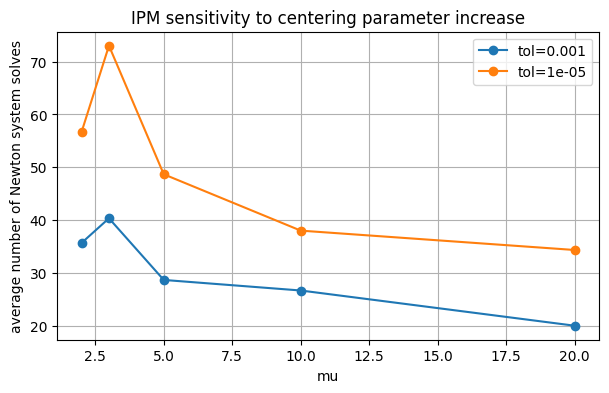

In [13]:
# YOUR CODE, PLOTS AND COMMENTS ARE HERE
np.random.seed(0)
N, D = 30, 12
mu_values = [2, 3, 5, 10, 20]
tolerances = [1e-3, 1e-5]
trials = 3

plt.figure(figsize=(7, 4))
for tol in tolerances:
    avg_solves = []
    for mu in mu_values:
        solves = []
        for _ in range(trials):
            X = np.random.randn(N, D)
            y = np.random.randn(N)
            opt_problem = {
                'XX': X.T.dot(X), 'Xy': X.T.dot(y), 'y2': y.dot(y),
                'lambda': 1 / N, 'N': N
            }
            w0 = np.zeros(D)
            t0 = np.ones(D)
            _, _, hist = ipm(w0, t0, opt_problem, mu=mu, tol_gap=tol, max_iter=30, disp='None')
            solves.append(hist['num_solve'][-1])
        avg_solves.append(np.mean(solves))
    plt.plot(mu_values, avg_solves, marker='o', label=f'tol={tol:g}')

plt.xlabel('mu')
plt.ylabel('average number of Newton system solves')
plt.title('IPM sensitivity to centering parameter increase')
plt.grid(True)
plt.legend()
plt.show()

### Task 2.6. Log-Barrier method behaviour w.r.t. problem dimension (0.5 pts)

Let's investigate the behaviour of Log-Barrier method w.r.t. problem dimension. Make two plots: 1) gap value w.r.t. iteration counter and 2) gap value w.r.t. time for different $D$ values. What can be said about this dependence? What can be said about Log-Barrier method's convergence speed?

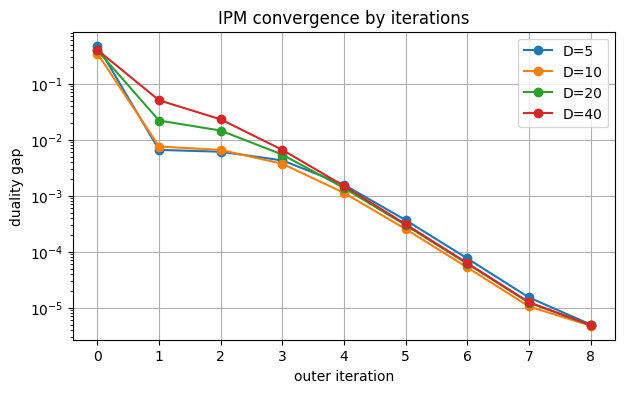

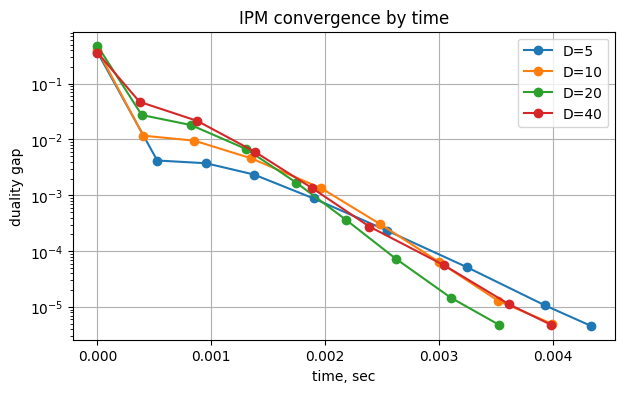

In [14]:
# YOUR CODE, PLOTS AND COMMENTS ARE HERE
np.random.seed(1)
N = 80
D_values = [5, 10, 20, 40]
plt.figure(figsize=(7, 4))
for D in D_values:
    X = np.random.randn(N, D)
    y = np.random.randn(N)
    opt_problem = {'XX': X.T.dot(X), 'Xy': X.T.dot(y), 'y2': y.dot(y), 'lambda': 1 / N, 'N': N}
    w0 = np.zeros(D)
    t0 = np.ones(D)
    _, _, hist = ipm(w0, t0, opt_problem, mu=5, tol_gap=1e-5, max_iter=30, disp='None')
    plt.semilogy(hist['gap'], marker='o', label=f'D={D}')
plt.xlabel('outer iteration')
plt.ylabel('duality gap')
plt.title('IPM convergence by iterations')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
for D in D_values:
    X = np.random.randn(N, D)
    y = np.random.randn(N)
    opt_problem = {'XX': X.T.dot(X), 'Xy': X.T.dot(y), 'y2': y.dot(y), 'lambda': 1 / N, 'N': N}
    w0 = np.zeros(D)
    t0 = np.ones(D)
    _, _, hist = ipm(w0, t0, opt_problem, mu=5, tol_gap=1e-5, max_iter=30, disp='None')
    plt.semilogy(hist['time'], hist['gap'], marker='o', label=f'D={D}')
plt.xlabel('time, sec')
plt.ylabel('duality gap')
plt.title('IPM convergence by time')
plt.grid(True)
plt.legend()
plt.show()

## Part 3 (1.5 pts): Subgradient method

Let's consider general convex non-smooth optimization problem 
$$
    F(\vec{w})\rightarrow\min_{\vec{w}}.
$$
Subgradient method has the following iterations:
\begin{align*}
    &\vec{w}_{k+1} = \vec{w}_k - \alpha_k\vec{z}_k,\\
    &\vec{z}_k \in\partial F(\vec{w}_k).
\end{align*}
Here $\alpha_k$ is a stepsize and $\vec{z}_k$ is some subgradient. An arbitrary subgradient is not a descend direction for the function $F$, hence the stepsize can not be automatically tuned by using Armijo-like condition. Besides, the output vector after $k$ iterations is determined as $\arg\min_{0\le i\le k}F(\vec{w}_i)$.

One possible option for stepsize is 
$$
    \alpha_k = \frac{\eta}{\sqrt{k+1}\|\vec{z}_k\|_2}.\quad (8)
$$
In this case the theoretical convergence speed of subgradient method is (ignoring logarithmic factors) $\tilde{O}(1/\sqrt{k})$. However, it is possible to find a better strategy for stepsize if the value $F_{opt}$ is known. Let's consider one step of subgradient method:
\begin{multline*}
    \|\vec{w}_{k+1} - \vec{w}_{opt}\|_2^2 = \|\vec{w}_k - \alpha_k\vec{z}_k - \vec{w}_{opt}\|_2^2 = 
    \|\vec{w}_k - \vec{w}_{opt}\|_2^2 - 2\alpha_k\vec{z}_k^T(\vec{w}_k - \vec{w}_{opt}) + \alpha_k^2\|\vec{z}_k\|_2^2 \le \\
    \le \|\vec{w}_k - \vec{w}_{opt}\|_2^2 - 2\alpha_k(F(\vec{w}_k) - F_{opt}) + \alpha_k^2\|\vec{z}_k\|_2^2 \rightarrow\min_{\alpha_k}.
\end{multline*}
Minimizing this parabola w.r.t. $\alpha_k$, we obtain:
$$
    \alpha_k = \frac{F(\vec{w}_k) - F_{opt}}{\|\vec{z}_k\|_2^2}\quad (9)
$$
In this case it can be shown that the convergence speed for subgradient method is $O(1/\sqrt{k})$ and does not have any logarithmic factors.

### Task 3.1. Subgradient method implementation (0.75 pts)

Let's implement subgradient method for the initial Lasso problem (1). The method scheme is the following:

- Input: initialization $\vec{w}_0$, duality gap tolerance $\varepsilon$.
- Compute the current duality gap: $gap = duality\_gap(\vec{w}_0)$;
- $gap_{best}=gap$;
- If $gap\le\varepsilon$, then stop.
- For $k=0,1,2,\dots,max\_iter$:
    - Compute subgradient $\vec{z}_k\in\partial F(\vec{w}_k)$;
    - Compute stepsize $\alpha_k$ using formulas (8) or (9) depending on chosen strategy;
    - $\vec{w}_{k+1} = \vec{w}_k - \alpha_k\vec{z}_k$;
    - Compute the current duality gap: $gap = duality\_gap(\vec{w}_{k+1})$;
    - If $gap < gap_{best}$, then $\vec{w}_{best} = \vec{w}_{k+1}$, $gap_{best} = gap$;
    - If $gap\le\varepsilon$, then return $\vec{w}_{best}$.
- Return $\vec{w}_{best}$.
 

In [15]:
def subgrad(w0, opt_problem, step_size_coef, step_size_strategy="diminishing", tol_gap=1e-3, max_iter=500, disp='None'):
    """
    Subgradient method for solving L1-regularized linear regression problem
    
    Inputs:
        w0 - initial value for weights
        opt_problem - optimization problem, dictionary with fields:
            'XX' - the matrix X^TX
            'Xy' - the product of X^T by the vector y
            'y2' - the value y^Ty, scalar
            'lambda' - regularization coefficient
            'N' - the number of objects
        step_size_coef - for optimal strategy the value of F_opt, 
                         for diminishing strategy the coefficient eta in the nominator of the formula (8)
        step_size_strategy - "optimal" or "diminishing"
        tol_gap - tolerance w.r.t. duality gap
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: 
                iteration counter, duality gap, current F_best, etc.
    
    Outputs:
        w - found solution
        hist - optimization history, e.g. dictionary with fields 'w', 'gap', 'F', 'time', 
            where the information about every iteration is stored. 
            You choose yourself the structure of this output.
    """
    
    # YOUR IMPLEMENTATION HERE
    XX = opt_problem['XX']
    Xy = opt_problem['Xy']
    y2 = opt_problem['y2']
    lambda_ = opt_problem['lambda']
    N = opt_problem['N']

    def objective(w):
        return 0.5 / N * (w.dot(XX.dot(w)) - 2.0 * w.dot(Xy) + y2) + lambda_ * np.sum(np.abs(w))

    w = w0.copy().astype(float)
    w_best = w.copy()
    F_best = objective(w)
    gap_best = duality_gap(w, opt_problem)
    hist = {'w': [w.copy()], 'gap': [gap_best], 'F': [F_best], 'time': [0.0], 'alpha': []}
    if gap_best <= tol_gap:
        return w_best, hist

    start_time = time.time()
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = range(max_iter)

    for k in iterator:
        z = (XX.dot(w) - Xy) / N + lambda_ * np.sign(w)
        z_norm2 = z.dot(z)
        if z_norm2 == 0:
            break

        F = objective(w)
        if step_size_strategy == 'optimal':
            alpha = max(F - step_size_coef, 0.0) / z_norm2
        elif step_size_strategy == 'diminishing':
            alpha = step_size_coef / (np.sqrt(k + 1.0) * np.sqrt(z_norm2))
        else:
            raise ValueError("step_size_strategy must be 'optimal' or 'diminishing'")

        w = w - alpha * z
        F = objective(w)
        gap = duality_gap(w, opt_problem)
        if gap < gap_best:
            gap_best = gap
            w_best = w.copy()
            F_best = F

        hist['w'].append(w.copy())
        hist['gap'].append(gap_best)
        hist['F'].append(F_best)
        hist['time'].append(time.time() - start_time)
        hist['alpha'].append(alpha)

        if disp == 'Iter':
            print(f'Subgrad iter {k:4d}: gap_best={gap_best:.3e}, F_best={F_best:.6e}, alpha={alpha:.3e}')
        if gap_best <= tol_gap:
            break

    return w_best, hist

In [16]:
# Some checks

# Check that for random small dataset subgradient method with optimal stepsize strategy
# can find solution with not so precise tolerance
N = 10
D = 8
X = np.random.randn(N, D)
y = np.random.randn(N)
lambda_ = 1/N
XX = X.T.dot(X)
Xy = X.T.dot(y)
y2 = y.dot(y)
opt_problem = {'XX': XX, 'Xy': Xy, 'y2': y2, 'lambda': lambda_, 'N': N}

w0 = np.random.randn(D)
t0 = np.abs(w0) + 1
w_opt, _, _ = ipm(w0, t0, opt_problem, tol_gap=1e-10, disp='None')
f_opt = (0.5/N)*(w_opt.dot(XX.dot(w_opt)) - 2*w_opt.dot(Xy) + y2) + lambda_*np.sum(np.abs(w_opt))

w, hist = subgrad(w0, opt_problem, step_size_coef = f_opt, step_size_strategy='optimal', tol_gap=1e-2, max_iter=500, disp='Progress')
gap = duality_gap(w, opt_problem)
assert gap <= 1e-2

### Task 3.2. Subgradient method behaviour w.r.t. stepsize strategy (0.75 pts)

Let's investigate convergence speed of subgradient method for different parameters in stepsize strategy. Make a plot of gap value w.r.t. iteration counter for optimal stepsize strategy and for diminishing strategy with different $\eta$. What can be said about convergence speed of subgradient method? Is it possible to find some diminishing strategy with better performance than for optimal strategy?

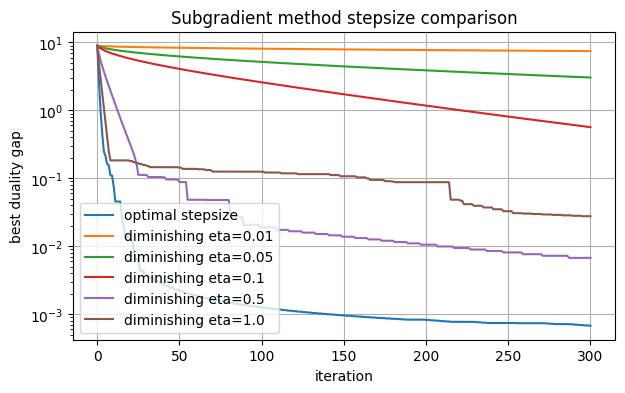

In [17]:
# YOUR CODE, PLOTS AND COMMENTS ARE HERE
np.random.seed(2)
N, D = 50, 20
X = np.random.randn(N, D)
y = np.random.randn(N)
opt_problem = {'XX': X.T.dot(X), 'Xy': X.T.dot(y), 'y2': y.dot(y), 'lambda': 1 / N, 'N': N}
w0 = np.random.randn(D)
w_ipm, _, _ = ipm(np.zeros(D), np.ones(D), opt_problem, tol_gap=1e-10, max_iter=50, disp='None')
f_opt = 0.5 / N * (w_ipm.dot(opt_problem['XX'].dot(w_ipm)) - 2 * w_ipm.dot(opt_problem['Xy']) + opt_problem['y2']) + opt_problem['lambda'] * np.sum(np.abs(w_ipm))

plt.figure(figsize=(7, 4))
_, hist = subgrad(w0, opt_problem, step_size_coef=f_opt, step_size_strategy='optimal', tol_gap=1e-6, max_iter=300, disp='None')
plt.semilogy(hist['gap'], label='optimal stepsize')
for eta in [0.01, 0.05, 0.1, 0.5, 1.0]:
    _, hist = subgrad(w0, opt_problem, step_size_coef=eta, step_size_strategy='diminishing', tol_gap=1e-6, max_iter=300, disp='None')
    plt.semilogy(hist['gap'], label=f'diminishing eta={eta}')
plt.xlabel('iteration')
plt.ylabel('best duality gap')
plt.title('Subgradient method stepsize comparison')
plt.grid(True)
plt.legend()
plt.show()

## Part 4 (1.5 pts): Proximal Gradient method

Let's consider a general composition optimization problem:
$$
    F(\vec{w}) = f(\vec{w}) + h(\vec{w})\rightarrow\min_{\vec{w}}.
$$
Here $f(\vec{w})$ is some smooth convex function and $h(\vec{w})$ is a non-smooth convex term. The proximal gradient method is based on using a standard Lipschitz upper bound for the smooth part:
$$
    F(\vec{w}) = f(\vec{w}) + h(\vec{w})\le f(\vec{w}_k) + \nabla f(\vec{w}_k)^T(\vec{w}-\vec{w}_k) + \frac{L}{2}\|\vec{w} - \vec{w}_k\|_2^2 + h(\vec{w})\rightarrow\min_{\vec{w}}.\quad (10)
$$
Here $L$ - a Lipschitz constant for gradient $\nabla f(\vec{w})$. Let's introduce a proximal operator:
$$
    \mathrm{prox}_h(\vec{v}) = \arg\min_{\vec{w}}\left(\frac{1}{2}\|\vec{w} - \vec{v}\|_2^2 + h(\vec{w})\right)
$$
Using this operator, the solution for the optimization problem (10) can be expressed as:
$$
    \vec{w}_{k+1} = \mathrm{prox}_{\frac{1}{L}h}(\vec{w}_k - \frac{1}{L}\nabla f(\vec{w}_k))
$$
The proximal gradient method is a descend method, i.e. $F(\vec{w}_{k+1})\le F(\vec{w}_k)$. For finding a suitable stepsize the following adaptation procedure can be used:

- Initialize $L$, $\gamma>1$;
- While True:
    - Make Prox-Grad optimization step with the current $L$: $\vec{w}_{k+1} = \mathrm{prox}_{\frac{1}{L}h}(\vec{w}_k - \frac{1}{L}\nabla f(\vec{w}_k))$;
    - If $f(\vec{w}_{k+1})\le f(\vec{w}_k) + \nabla f(\vec{w}_k)^T(\vec{w}_{k+1}-\vec{w}_k) + \frac{L}{2}\|\vec{w}_{k+1} - \vec{w}_k\|_2^2$, then break;
    - $L = L*\gamma$;
- Try reduced value $L = L/\gamma$ for the next iteration.
    

### Task 4.1. ProxGrad implementation (0.75 pts)

Let's implement Proximal Gradient method for the initial optimization problem (1).

In [18]:
def proxgrad(w0, opt_problem, tol_gap=1e-3, max_iter=100, disp='None'):
    """
    Proximal Gradient method for L1-regularized linear regression
    
    Inputs:
        w0 - initial weights
        opt_problem, optimal problem, dictionary with fields:
            'XX' - the matrix X^TX
            'Xy' - the product X^Ty
            'y2' - the value y^Ty
            'lambda' - regularization coefficient
            'N' - the number of objects
        tol_gap - gap tolerance
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: 
                iteration counter, duality gap, etc.
    
    Outputs:
        w - found solution
        hist - optimization history, e.g. dictionary with fields 'w', 'gap', 'L', 'time', 
            where the information about every iteration is stored. 
            You choose yourself the structure of this output.
    """
    
    # YOUR IMPLEMENTATION HERE
    XX = opt_problem['XX']
    Xy = opt_problem['Xy']
    y2 = opt_problem['y2']
    lambda_ = opt_problem['lambda']
    N = opt_problem['N']

    def smooth_value(w):
        return 0.5 / N * (w.dot(XX.dot(w)) - 2.0 * w.dot(Xy) + y2)

    def objective(w):
        return smooth_value(w) + lambda_ * np.sum(np.abs(w))

    def soft_threshold(v, alpha):
        return np.sign(v) * np.maximum(np.abs(v) - alpha, 0.0)

    w = w0.copy().astype(float)
    gap = duality_gap(w, opt_problem)
    hist = {'w': [w.copy()], 'gap': [gap], 'L': [], 'time': [0.0], 'F': [objective(w)]}
    if gap <= tol_gap:
        return w, hist

    L = max(1.0, np.linalg.norm(XX, ord=2) / N / 10.0)
    gamma = 2.0
    start_time = time.time()
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = range(max_iter)

    for k in iterator:
        f = smooth_value(w)
        grad = (XX.dot(w) - Xy) / N
        while True:
            w_new = soft_threshold(w - grad / L, lambda_ / L)
            d = w_new - w
            if smooth_value(w_new) <= f + grad.dot(d) + 0.5 * L * d.dot(d) + 1e-14:
                break
            L *= gamma

        w = w_new
        gap = duality_gap(w, opt_problem)
        hist['w'].append(w.copy())
        hist['gap'].append(gap)
        hist['L'].append(L)
        hist['time'].append(time.time() - start_time)
        hist['F'].append(objective(w))

        if disp == 'Iter':
            print(f'ProxGrad iter {k:4d}: gap={gap:.3e}, L={L:.3e}')
        if gap <= tol_gap:
            break

    return w, hist

In [19]:
# Some checks

# Check that for small random dataset a proximal gradient method
# can indeed find solution with given tolerance
N = 10
D = 8
X = np.random.randn(N, D)
y = np.random.randn(N)
lambda_ = 1/N
XX = X.T.dot(X)
Xy = X.T.dot(y)
y2 = y.dot(y)
opt_problem = {'XX': XX, 'Xy': Xy, 'y2': y2, 'lambda': lambda_, 'N': N}

w0 = np.random.randn(D)
w, hist = proxgrad(w0, opt_problem, tol_gap=1e-3, max_iter=200, disp='None')
gap = duality_gap(w, opt_problem)
assert gap <= 1e-3

### Task 4.2. ProxGrad convergence behaviour (0.75 pts)

Let's investigate the convergence speed of proximal gradient method. Make a plot of duality gap value w.r.t. iteration counter for some random dataset. What can be said about observed convergence speed? Does this behaviour depend on problem size? 

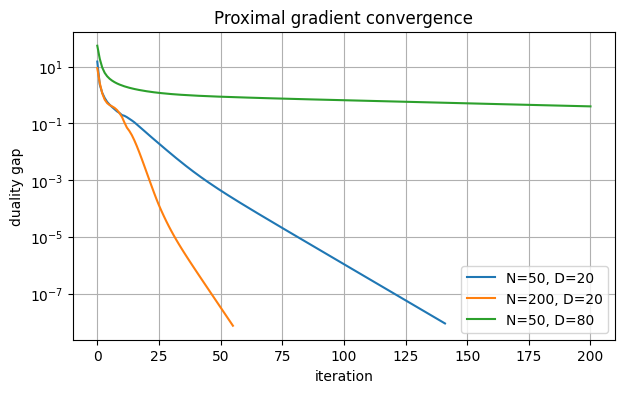

In [20]:
# YOUR CODE, PLOTS AND COMMENTS ARE HERE
np.random.seed(3)
settings = [(50, 20), (200, 20), (50, 80)]
plt.figure(figsize=(7, 4))
for N, D in settings:
    X = np.random.randn(N, D)
    y = np.random.randn(N)
    opt_problem = {'XX': X.T.dot(X), 'Xy': X.T.dot(y), 'y2': y.dot(y), 'lambda': 1 / N, 'N': N}
    w0 = np.random.randn(D)
    _, hist = proxgrad(w0, opt_problem, tol_gap=1e-8, max_iter=200, disp='None')
    plt.semilogy(hist['gap'], label=f'N={N}, D={D}')
plt.xlabel('iteration')
plt.ylabel('duality gap')
plt.title('Proximal gradient convergence')
plt.grid(True)
plt.legend()
plt.show()

## Part 5 (1.5 pts): ADMM method

Lasso problem can be solved by ADMM method in the following form:
\begin{align*}
    &\frac{1}{2N}\|X\vec{w}-\vec{y}\|_2^2 + \lambda\|\vec{z}\|_1\rightarrow\min_{\vec{w},\vec{z}},\\
    &\vec{w} = \vec{z}.
\end{align*}

Augmented Lagrangian function in scaled version:
$$
    L_{\rho}(\vec{w},\vec{z},\vec{u}) = \frac{1}{2N}\|X\vec{w}-\vec{y}\|_2^2 + \lambda\|\vec{z}\|_1 + \frac{\rho}{2}\|\vec{w}-\vec{z}+\vec{u}\|_2^2.
$$

One ADMM step:
\begin{align*}
    &\vec{w}_{k+1} = \arg\min_{\vec{w}}L_{\rho}(\vec{w},\vec{z}_k,\vec{u}_k) = \left(\frac{1}{N}X^TX + \rho I\right)^{-1}\left(\frac{1}{N}X^T\vec{y} + \rho(\vec{z}_k-\vec{u}_k)\right);\\
    &\vec{z}_{k+1} = \arg\min_{\vec{z}}L_{\rho}(\vec{w}_{k+1},\vec{z},\vec{u}_k) = \mathrm{prox}_{\frac{\lambda}{\rho}\|\cdot\|_1}(\vec{w}_{k+1}+\vec{u}_k);\\
    &\vec{u}_{k+1} = \vec{u}_k + \vec{w}_{k+1} - \vec{z}_{k+1}.
\end{align*}

In practice $\rho$ adaptation procedure can be useful. For this reason we can compute primal and dual residuals:
\begin{align*}
    &r_k = \|\vec{w}_k - \vec{z}_k\|,\\
    &s_k = \|\rho(\vec{z}_k - \vec{z}_{k-1})\|.
\end{align*}
In ideal case both residuals should be of the same scale and evenly decrease to zero. If some inbalance is observed, then it is reasonable to adapt $\rho$:

For every $M$-th iteration:
- If $r_k\ge\gamma s_k$, then: $\rho_{new} = \rho*\tau$, $\vec{u}_{new} = \vec{u}/\tau$;
- If $s_k\ge\gamma r_k$, then: $\rho_{new} = \rho/\tau$, $\vec{u}_{new} = \vec{u}*\tau$.

Typical parameters: $M=10, \gamma=10, \tau=2$.

For computational convenience, if case of fixed $\rho$ the matrix $\frac{1}{N}X^TX + \rho I$ can be decomposed into Cholesky once on the start of optimization. For adapting $\rho$ for the matrix $\frac{1}{N}X^TX$ eigenvalue decomposition can be computed on the start and then reused: $\frac{1}{N}X^TX = Q\Lambda Q^T$, $\frac{1}{N}X^TX + \rho I = Q(\Lambda + \rho I)Q^T$.

### Task 5.1. ADMM implementation (0.75 pts)

In [21]:
def admm(w0, opt_problem, rho=1, tol_gap=1e-3, max_iter=100, disp='None'):
    """
    ADMM method for L1-regularized linear regression
    
    Inputs:
        w0 - initial weights
        opt_problem, optimal problem, dictionary with fields:
            'XX' - the matrix X^TX
            'Xy' - the product X^Ty
            'y2' - the value y^Ty
            'lambda' - regularization coefficient
            'N' - the number of objects
        rho - rho value, if rho=0 then adaptive procedure is used
        tol_gap - gap tolerance
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: 
                iteration counter, duality gap, etc.
    
    Outputs:
        w - found solution
        hist - optimization history, e.g. dictionary with fields 'w', 'gap', 'time', 
            where the information about every iteration is stored. 
            You choose yourself the structure of this output.
    """
    
    # YOUR IMPLEMENTATION HERE
    XX = opt_problem['XX']
    Xy = opt_problem['Xy']
    lambda_ = opt_problem['lambda']
    N = opt_problem['N']
    D = w0.size

    def soft_threshold(v, alpha):
        return np.sign(v) * np.maximum(np.abs(v) - alpha, 0.0)

    adaptive = (rho == 0)
    rho_cur = 1.0 if adaptive else float(rho)
    w = w0.copy().astype(float)
    z = w.copy()
    u = np.zeros_like(w)

    gap = duality_gap(w, opt_problem)
    hist = {'w': [w.copy()], 'z': [z.copy()], 'gap': [gap], 'time': [0.0], 'rho': [rho_cur], 'r': [], 's': []}
    if gap <= tol_gap:
        return w, hist

    start_time = time.time()
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = range(max_iter)

    A = XX / N + rho_cur * np.eye(D)
    factor = None

    for k in iterator:
        if factor is None:
            try:
                factor = sp.linalg.cho_factor(A, lower=True, check_finite=False)
                solve = lambda rhs: sp.linalg.cho_solve(factor, rhs, check_finite=False)
            except np.linalg.LinAlgError:
                solve = lambda rhs: np.linalg.solve(A, rhs)

        z_old = z.copy()
        rhs = Xy / N + rho_cur * (z - u)
        w = solve(rhs)
        z = soft_threshold(w + u, lambda_ / rho_cur)
        u = u + w - z

        r = np.linalg.norm(w - z)
        s = np.linalg.norm(rho_cur * (z - z_old))

        if adaptive:
            old_rho = rho_cur
            if r > 10.0 * s:
                rho_cur *= 2.0
            elif s > 10.0 * r:
                rho_cur /= 2.0
            if rho_cur != old_rho:
                u *= old_rho / rho_cur  # keep the unscaled multiplier fixed
                A = XX / N + rho_cur * np.eye(D)
                factor = None

        gap = duality_gap(w, opt_problem)
        hist['w'].append(w.copy())
        hist['z'].append(z.copy())
        hist['gap'].append(gap)
        hist['time'].append(time.time() - start_time)
        hist['rho'].append(rho_cur)
        hist['r'].append(r)
        hist['s'].append(s)

        if disp == 'Iter':
            print(f'ADMM iter {k:4d}: gap={gap:.3e}, rho={rho_cur:.3e}, r={r:.3e}, s={s:.3e}')
        if gap <= tol_gap:
            break

    return w, hist

In [22]:
# Some checks

# Check that for small random dataset ADMM method
# can indeed find solution with given tolerance
N = 10
D = 8
X = np.random.randn(N, D)
y = np.random.randn(N)
lambda_ = 1/N
XX = X.T.dot(X)
Xy = X.T.dot(y)
y2 = y.dot(y)
opt_problem = {'XX': XX, 'Xy': Xy, 'y2': y2, 'lambda': lambda_, 'N': N}

w0 = np.random.randn(D)
w, hist = admm(w0, opt_problem, rho=1, tol_gap=1e-3, max_iter=200, disp='None')
gap = duality_gap(w, opt_problem)
assert gap <= 1e-3

### Task 5.2. ADMM convergence speed and dependence on $\rho$ (0.75 pts)

Let's investigate the convergence speed of ADMM and its dependence on $\rho$ parameter. Make a plot of duality gap value w.r.t. iteration counter for some random dataset for several fixed $\rho$ values and for $\rho$ adapting strategy. What can be said about observed convergence speed? How adaptive strategy corresponds to fix $\rho $?

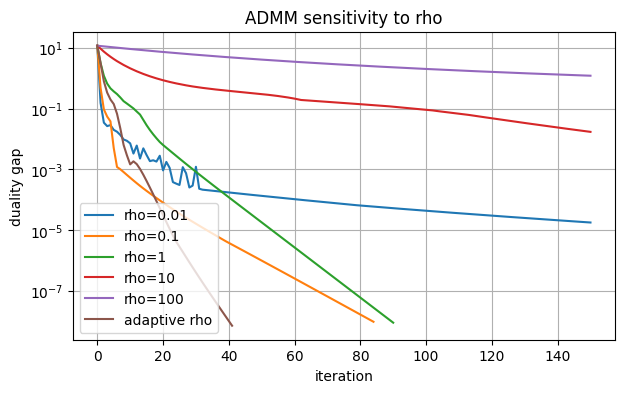

In [23]:
# YOUR CODE, PLOTS AND COMMENTS ARE HERE
np.random.seed(4)
N, D = 80, 30
X = np.random.randn(N, D)
y = np.random.randn(N)
opt_problem = {'XX': X.T.dot(X), 'Xy': X.T.dot(y), 'y2': y.dot(y), 'lambda': 1 / N, 'N': N}
w0 = np.random.randn(D)

plt.figure(figsize=(7, 4))
for rho in [0.01, 0.1, 1.0, 10.0, 100.0, 0]:
    _, hist = admm(w0, opt_problem, rho=rho, tol_gap=1e-8, max_iter=150, disp='None')
    label = 'adaptive rho' if rho == 0 else f'rho={rho:g}'
    plt.semilogy(hist['gap'], label=label)
plt.xlabel('iteration')
plt.ylabel('duality gap')
plt.title('ADMM sensitivity to rho')
plt.grid(True)
plt.legend()
plt.show()

## Part 6 (2 pts): Comparison of all methods

Now let's compare the performance of all methods (ipm, subgrad, proxgrad and admm) on different datasets. For each dataset make a plot of duality gap for all methods w.r.t. 1) iteration counter and 2) training time. Use random datasets with different ratio between $N$ and $D$ and also **abalone_scale** dataset from [LibSVM collection](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/). Which method is the best one? Does the answer depend on given tolerance for duality gap? Does the answer depend on regularization coefficient $\lambda$?

abalone_scale was not found locally; using only synthetic datasets in this run.


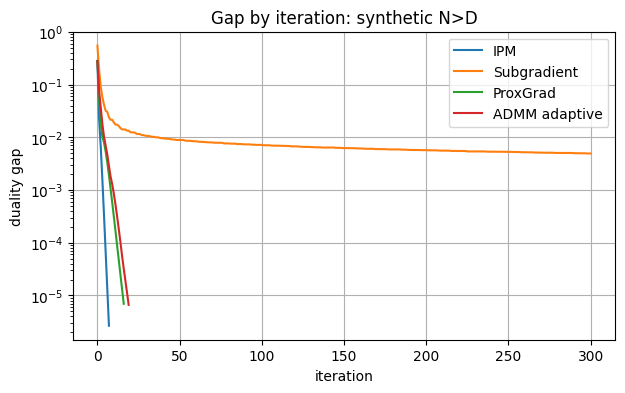

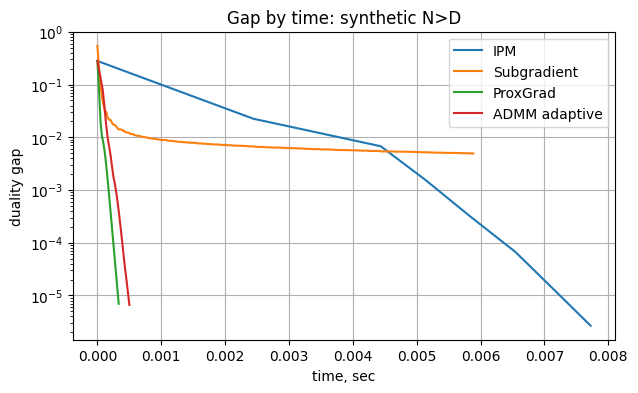

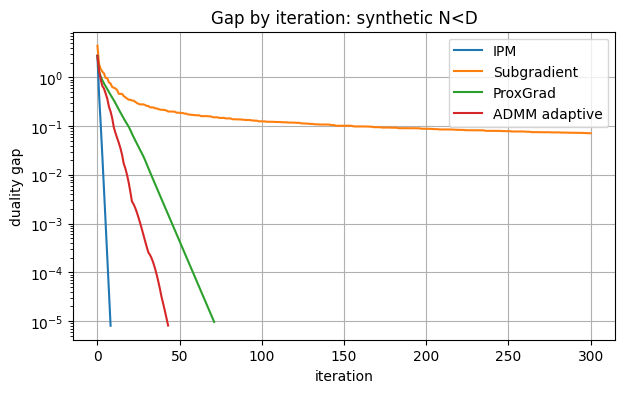

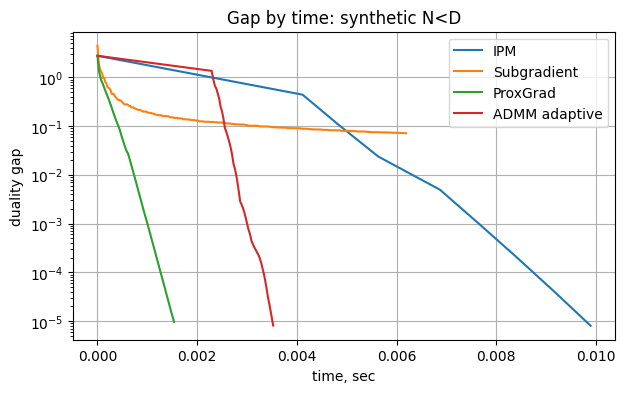

In [24]:
def make_problem(X, y, lambda_scale=0.1):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    N = X.shape[0]
    XX = X.T.dot(X)
    Xy = X.T.dot(y)
    lambda_max = np.max(np.abs(Xy)) / N
    return {'XX': XX, 'Xy': Xy, 'y2': y.dot(y), 'lambda': lambda_scale * lambda_max, 'N': N}

def objective_value(w, opt_problem):
    return 0.5 / opt_problem['N'] * (w.dot(opt_problem['XX'].dot(w)) - 2 * w.dot(opt_problem['Xy']) + opt_problem['y2']) + opt_problem['lambda'] * np.sum(np.abs(w))

np.random.seed(5)
datasets = []
for N, D, name in [(120, 30, 'synthetic N>D'), (40, 80, 'synthetic N<D')]:
    X = np.random.randn(N, D)
    true_w = np.zeros(D)
    true_w[:max(1, D // 10)] = np.random.randn(max(1, D // 10))
    y = X.dot(true_w) + 0.1 * np.random.randn(N)
    datasets.append((name, X, y))

try:
    X_ab, y_ab = load_svmlight_file('abalone_scale')
    datasets.append(('abalone_scale', X_ab.toarray(), y_ab))
except Exception:
    print('abalone_scale was not found locally; using only synthetic datasets in this run.')

for name, X, y in datasets:
    opt_problem = make_problem(X, y, lambda_scale=0.1)
    D = X.shape[1]
    w0 = np.zeros(D)
    t0 = np.ones(D)

    w_ipm, _, hist_ipm = ipm(w0, t0, opt_problem, mu=5, tol_gap=1e-5, max_iter=40, disp='None')
    f_opt = objective_value(w_ipm, opt_problem)
    _, hist_sub = subgrad(w0 + 0.1 * np.random.randn(D), opt_problem, step_size_coef=f_opt, step_size_strategy='optimal', tol_gap=1e-5, max_iter=300, disp='None')
    _, hist_pg = proxgrad(w0, opt_problem, tol_gap=1e-5, max_iter=300, disp='None')
    _, hist_admm = admm(w0, opt_problem, rho=0, tol_gap=1e-5, max_iter=300, disp='None')

    plt.figure(figsize=(7, 4))
    plt.semilogy(hist_ipm['gap'], label='IPM')
    plt.semilogy(hist_sub['gap'], label='Subgradient')
    plt.semilogy(hist_pg['gap'], label='ProxGrad')
    plt.semilogy(hist_admm['gap'], label='ADMM adaptive')
    plt.xlabel('iteration')
    plt.ylabel('duality gap')
    plt.title(f'Gap by iteration: {name}')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.semilogy(hist_ipm['time'], hist_ipm['gap'], label='IPM')
    plt.semilogy(hist_sub['time'], hist_sub['gap'], label='Subgradient')
    plt.semilogy(hist_pg['time'], hist_pg['gap'], label='ProxGrad')
    plt.semilogy(hist_admm['time'], hist_admm['gap'], label='ADMM adaptive')
    plt.xlabel('time, sec')
    plt.ylabel('duality gap')
    plt.title(f'Gap by time: {name}')
    plt.grid(True)
    plt.legend()
    plt.show()